"""
=============================================================================
ML Day 4: Linear Regression with Statsmodels & Scikit-Learn
=============================================================================
A comprehensive guide to building robust linear regression models by combining
the statistical power of statsmodels with the practical flexibility of scikit-learn.

Topics covered:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing (Standardization & Encoding)
3. Model Implementation (both packages)
4. Model Optimization & Comparison
=============================================================================
"""

In [8]:
# ============================================================================
# STEP 0: Import Libraries
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("="*80)
print("ML DAY 4: LINEAR REGRESSION LEARNING PATH")
print("="*80)

ML DAY 4: LINEAR REGRESSION LEARNING PATH


In [10]:
# ============================================================================
# STEP 1: CREATING A SAMPLE DATASET
# ============================================================================
print("\n" + "="*80)
print("STEP 1: CREATING A SAMPLE DATASET")
print("="*80)

"""
For learning purposes, we'll create a dataset with:
- Numerical features: Age, Income, Years_Experience
- Categorical features: Education_Level, Department
- Target: House_Price

In real scenarios, you'd load data with pd.read_csv() or similar.
"""

n_samples = 200
data = {
    'Age': np.random.randint(22, 65, n_samples),
    'Income': np.random.randint(30000, 150000, n_samples),
    'Years_Experience': np.random.randint(0, 30, n_samples),
    'Education_Level': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_samples),
    'Department': np.random.choice(['Sales', 'IT', 'HR', 'Finance'], n_samples),
}

# Create target variable with some relationship to features
df = pd.DataFrame(data)
df['House_Price'] = (
    50000 +
    1000 * df['Age'] +
    0.5 * df['Income'] +
    5000 * df['Years_Experience'] +
    np.random.normal(0, 20000, n_samples)  # Add noise
)

print("\n✓ Dataset created successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:\n{df.head()}")


STEP 1: CREATING A SAMPLE DATASET

✓ Dataset created successfully!
Shape: (200, 6)

First few rows:
   Age  Income  Years_Experience Education_Level Department    House_Price
0   60   82662                25          Master      Sales  308903.310911
1   50  128506                16        Bachelor         HR  216650.970836
2   36  139751                 7          Master      Sales  156807.851213
3   64  148906                 0          Master    Finance  187342.046022
4   29   42688                 8     High School         IT  148025.308979


In [22]:
# ============================================================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "="*80)
print("STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# 2.1: Basic Statistics
print("\n--- Basic Statistics ---")
print(df.describe())

# 2.2: Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 2.3: Data types
print("\n--- Data Types ---")
print(df.dtypes)

# 2.4: Correlation Analysis (Numerical variables)
print("\n--- Correlation with Target Variable ---")
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[numerical_cols].corr()['House_Price'].sort_values(ascending=False))


STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

--- Basic Statistics ---
              Age         Income  Years_Experience    House_Price
count  200.000000     200.000000        200.000000     200.000000
mean    42.955000   88119.245000         15.185000  211513.329578
std     12.754858   36197.778957          9.093638   54687.650566
min     22.000000   30301.000000          0.000000   89368.505381
25%     31.750000   58634.500000          7.000000  170317.585366
50%     45.000000   83698.000000         15.000000  213006.913060
75%     54.000000  120387.750000         23.000000  252215.820686
max     64.000000  149181.000000         29.000000  351922.116169

--- Missing Values ---
Age                 0
Income              0
Years_Experience    0
Education_Level     0
Department          0
House_Price         0
dtype: int64

--- Data Types ---
Age                   int64
Income                int64
Years_Experience      int64
Education_Level      object
Department           object
House_Pric

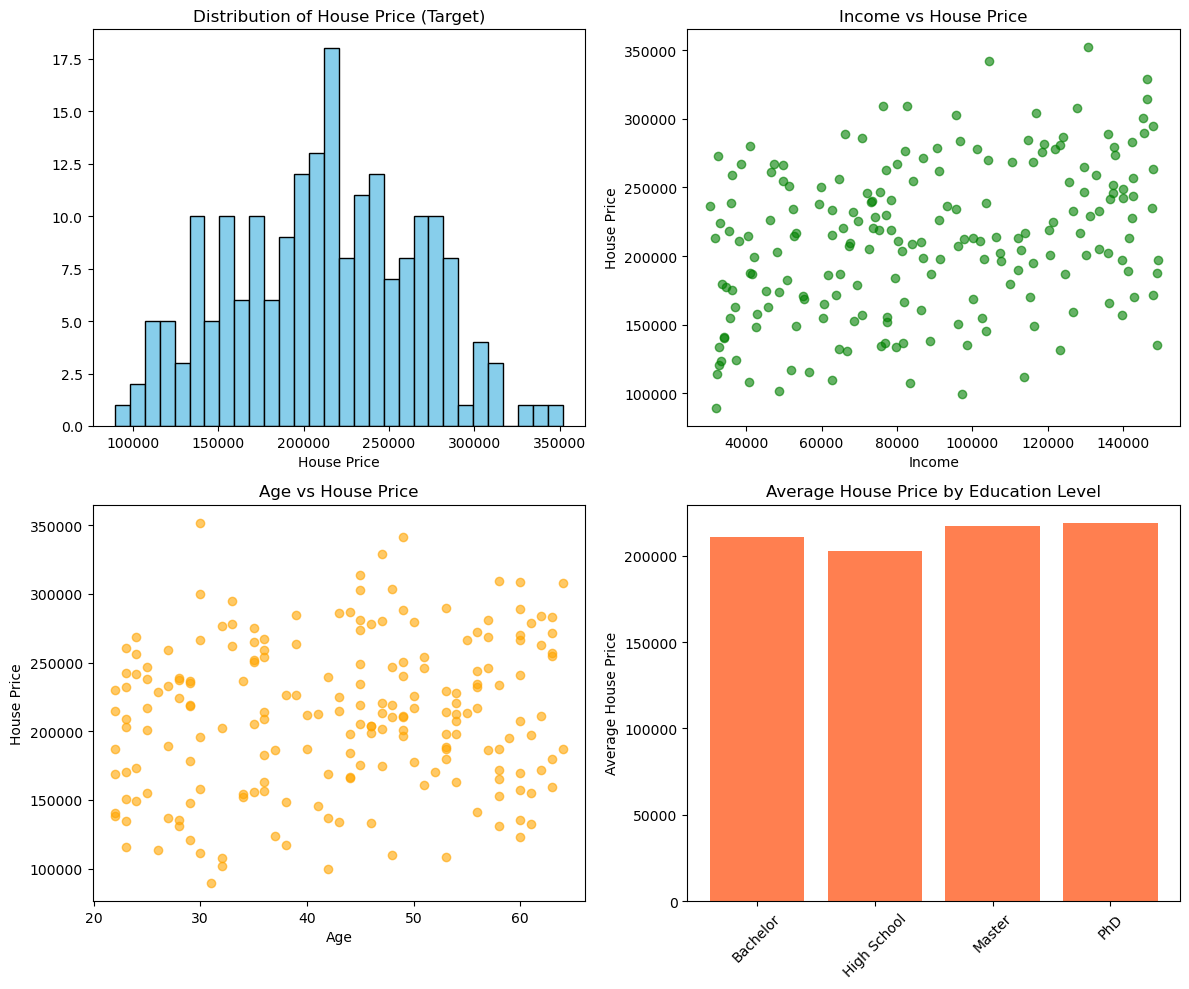

In [36]:
# 2.5: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution of target variable
axes[0, 0].hist(df['House_Price'], bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Distribution of House Price (Target)')
axes[0, 0].set_xlabel('House Price')

# Relationship between Income and House Price
axes[0, 1].scatter(df['Income'], df['House_Price'], alpha=0.6, color='green')
axes[0, 1].set_title('Income vs House Price')
axes[0, 1].set_xlabel('Income')
axes[0, 1].set_ylabel('House Price')

# Relationship between Age and House Price
axes[1, 0].scatter(df['Age'], df['House_Price'], alpha=0.6, color='orange')
axes[1, 0].set_title('Age vs House Price')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('House Price')

# Categorical variable: Education Level
education_price = df.groupby('Education_Level')['House_Price'].mean()
axes[1, 1].bar(education_price.index, education_price.values, color='coral')
axes[1, 1].set_title('Average House Price by Education Level')
axes[1, 1].set_ylabel('Average House Price')
plt.xticks(rotation=45)
plt.tight_layout()

In [48]:
# ============================================================================
# STEP 3: DATA PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("STEP 3: DATA PREPROCESSING")
print("="*80)

# 3.1: Separate features and target
print("\n--- Separating Features and Target ---")
X = df.drop('House_Price', axis=1)
y = df['House_Price']
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


# 3.2: Identify numerical and categorical columns
print("\n--- Column Classification ---")
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")


# 3.3: Handle Categorical Variables (Create Dummy Variables)
print("\n--- Creating Dummy Variables for Categorical Features ---")
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print(f"Shape after encoding: {X_encoded.shape}")
print(f"New features: {X_encoded.columns.tolist()}")


# 3.4: Standardize Numerical Variables
print("\n--- Standardizing Numerical Variables ---")
"""
Why standardize?
- Brings all features to the same scale (mean=0, std=1)
- Important for algorithms sensitive to feature magnitude
- Helps with model interpretation and convergence
- Some optimization algorithms work better with scaled data
"""
scaler = StandardScaler()
X_encoded_scaled = X_encoded.copy()
X_encoded_scaled[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

print(f"Scaled numerical features statistics:")
print(X_encoded_scaled[numerical_features].describe())


# 3.5: Train-Test Split
print("\n--- Train-Test Split (80-20) ---")
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_scaled, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


STEP 3: DATA PREPROCESSING

--- Separating Features and Target ---
X shape: (200, 5)
y shape: (200,)

--- Column Classification ---
Numerical features: ['Age', 'Income', 'Years_Experience']
Categorical features: ['Education_Level', 'Department']

--- Creating Dummy Variables for Categorical Features ---
Shape after encoding: (200, 9)
New features: ['Age', 'Income', 'Years_Experience', 'Education_Level_High School', 'Education_Level_Master', 'Education_Level_PhD', 'Department_HR', 'Department_IT', 'Department_Sales']

--- Standardizing Numerical Variables ---
Scaled numerical features statistics:
                Age        Income  Years_Experience
count  2.000000e+02  2.000000e+02      2.000000e+02
mean   1.243450e-16  1.310063e-16     -6.217249e-17
std    1.002509e+00  1.002509e+00      1.002509e+00
min   -1.647026e+00 -1.601295e+00     -1.674039e+00
25%   -8.806933e-01 -8.165897e-01     -9.023385e-01
50%    1.607334e-01 -1.224478e-01     -2.039495e-02
75%    8.681176e-01  8.936869e-0

In [58]:
# ============================================================================
# STEP 4: MODEL IMPLEMENTATION - SCIKIT-LEARN
# ============================================================================
print("\n" + "="*80)
print("STEP 4A: MODEL IMPLEMENTATION - SCIKIT-LEARN")
print("="*80)

"""
Scikit-learn is great for:
- Quick model building and prediction
- Easy hyperparameter tuning
- Cross-validation and model selection
- Production-ready code
"""

print("\n--- Training Scikit-Learn Linear Regression ---")
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

print("✓ Model trained successfully!")

# Make predictions
y_train_pred_sklearn = sklearn_model.predict(X_train)
y_test_pred_sklearn = sklearn_model.predict(X_test)


# Evaluation metrics
train_r2_sklearn = r2_score(y_train, y_train_pred_sklearn)
test_r2_sklearn = r2_score(y_test, y_test_pred_sklearn)
train_rmse_sklearn = np.sqrt(mean_squared_error(y_train, y_train_pred_sklearn))
test_rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_test_pred_sklearn))
train_mae_sklearn = mean_absolute_error(y_train, y_train_pred_sklearn)
test_mae_sklearn = mean_absolute_error(y_test, y_test_pred_sklearn)


print("\n--- Scikit-Learn Model Performance ---")
print(f"Training R² Score: {train_r2_sklearn:.4f}")
print(f"Test R² Score: {test_r2_sklearn:.4f}")
print(f"Training RMSE: ${train_rmse_sklearn:,.2f}")
print(f"Test RMSE: ${test_rmse_sklearn:,.2f}")
print(f"Training MAE: ${train_mae_sklearn:,.2f}")
print(f"Test MAE: ${test_mae_sklearn:,.2f}")


# Model coefficients
print("\n--- Feature Coefficients (Importance) ---")
coefficients = pd.DataFrame({
    'Feature': X_encoded_scaled.columns,
    'Coefficient': sklearn_model.coef_
}).sort_values('Coefficient', ascending=False)
print(coefficients)


STEP 4A: MODEL IMPLEMENTATION - SCIKIT-LEARN

--- Training Scikit-Learn Linear Regression ---
✓ Model trained successfully!

--- Scikit-Learn Model Performance ---
Training R² Score: 0.8753
Test R² Score: 0.8432
Training RMSE: $19,475.02
Test RMSE: $20,190.23
Training MAE: $15,214.06
Test MAE: $16,447.81

--- Feature Coefficients (Importance) ---
                       Feature   Coefficient
2             Years_Experience  47419.401605
1                       Income  18575.647068
0                          Age  12531.777729
4       Education_Level_Master   5780.021714
3  Education_Level_High School   4192.899729
5          Education_Level_PhD   -591.048146
7                Department_IT  -2676.536802
8             Department_Sales  -2949.557886
6                Department_HR  -6297.050619


In [76]:
# ============================================================================
# STEP 4B: MODEL IMPLEMENTATION - STATSMODELS
# ============================================================================
print("\n" + "="*80)
print("STEP 4B: MODEL IMPLEMENTATION - STATSMODELS")
print("="*80)

"""
Statsmodels is great for:
- Statistical inference and hypothesis testing
- Understanding p-values, confidence intervals, F-statistics
- Detailed diagnostic reports
- Advanced regression diagnostics
"""

print("\n--- Training Statsmodels OLS Regression ---")

# Convert to numpy arrays with float dtype to avoid statsmodels dtype issues
X_train_array = X_train.astype(float).values
X_test_array = X_test.astype(float).values
y_train_array = y_train.astype(float).values
y_test_array = y_test.astype(float).values

# Add constant (intercept) term
X_train_sm = sm.add_constant(X_train_array)
X_test_sm = sm.add_constant(X_test_array)

# Fit the model
statsmodels_model = sm.OLS(y_train_array, X_train_sm).fit()

print("✓ Model trained successfully!")
print(f"\n{statsmodels_model.summary()}")

# Make predictions
y_train_pred_sm = statsmodels_model.predict(X_train_sm)
y_test_pred_sm = statsmodels_model.predict(X_test_sm)

# Evaluation metrics
train_r2_sm = r2_score(y_train_array, y_train_pred_sm)
test_r2_sm = r2_score(y_test_array, y_test_pred_sm)
train_rmse_sm = np.sqrt(mean_squared_error(y_train_array, y_train_pred_sm))
test_rmse_sm = np.sqrt(mean_squared_error(y_test_array, y_test_pred_sm))

print("\n--- Statsmodels Model Performance ---")
print(f"Training R² Score: {train_r2_sm:.4f}")
print(f"Test R² Score: {test_r2_sm:.4f}")
print(f"Training RMSE: ${train_rmse_sm:,.2f}")
print(f"Test RMSE: ${test_rmse_sm:,.2f}")


STEP 4B: MODEL IMPLEMENTATION - STATSMODELS

--- Training Statsmodels OLS Regression ---
✓ Model trained successfully!

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     117.0
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           3.43e-63
Time:                        12:46:59   Log-Likelihood:                -1807.3
No. Observations:                 160   AIC:                             3635.
Df Residuals:                     150   BIC:                             3665.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------


STEP 5: MODEL DIAGNOSTICS & ASSUMPTIONS CHECK

--- Residual Statistics ---
Mean of residuals: 1543.8321 (should be close to 0)
Std of residuals: 20387.5770

--- Variance Inflation Factor (VIF) - Multicollinearity Check ---
                       Feature       VIF
7                Department_IT  1.866475
3  Education_Level_High School  1.823127
8             Department_Sales  1.632453
5          Education_Level_PhD  1.569557
4       Education_Level_Master  1.457820
6                Department_HR  1.413388
0                          Age  1.097801
2             Years_Experience  1.090956
1                       Income  1.049275

Note: VIF > 5-10 indicates potential multicollinearity issues


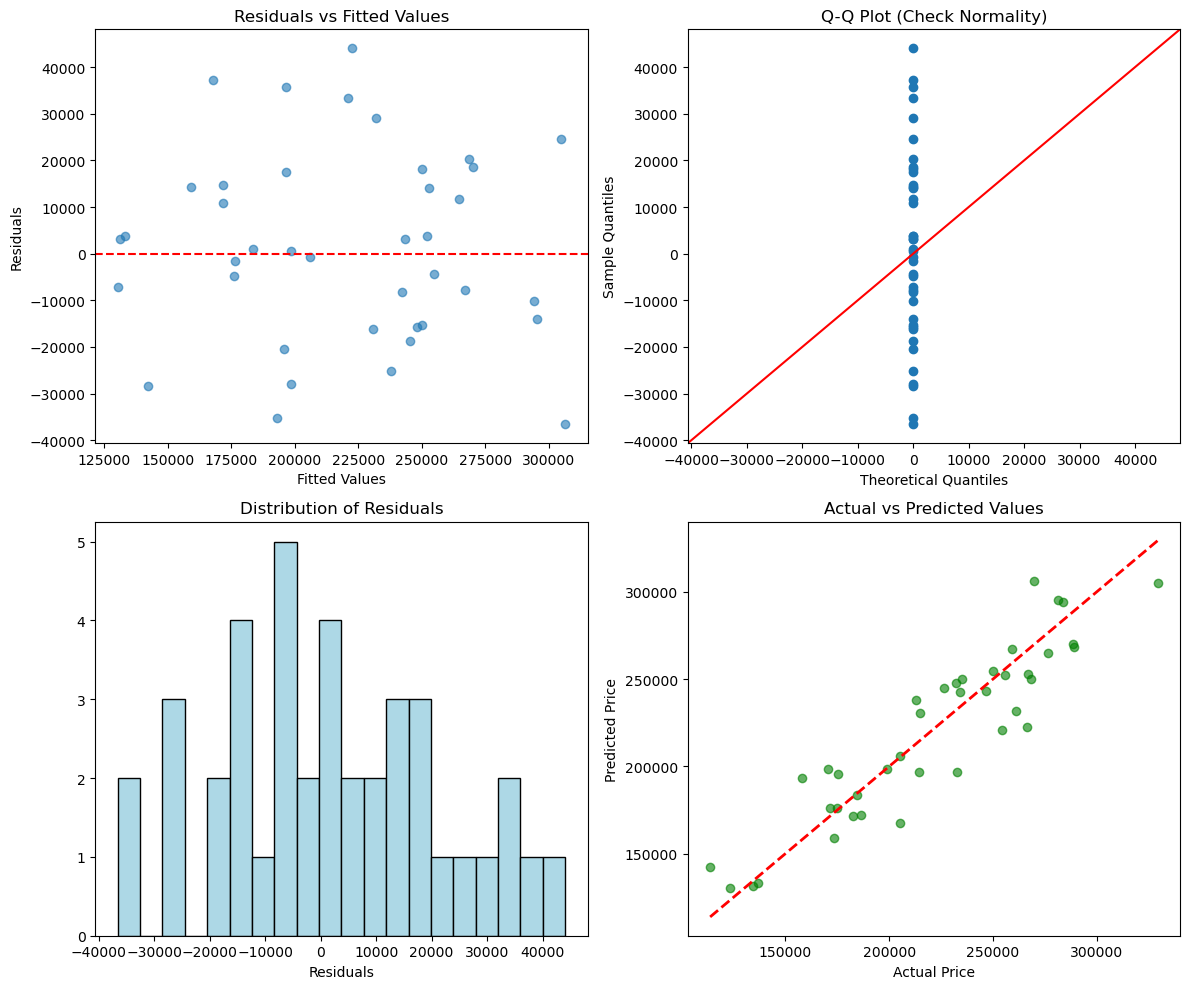

In [82]:
# ============================================================================
# STEP 5: MODEL DIAGNOSTICS (Statsmodels advantage)
# ============================================================================
print("\n" + "="*80)
print("STEP 5: MODEL DIAGNOSTICS & ASSUMPTIONS CHECK")
print("="*80)

"""
Important Linear Regression Assumptions:
1. Linearity: Relationship between X and y is linear
2. Independence: Observations are independent
3. Homoscedasticity: Constant variance of residuals
4. Normality: Residuals follow normal distribution
5. No multicollinearity: Features are not too correlated
"""

# 5.1: Residual Analysis
residuals = y_test - y_test_pred_sm

print("\n--- Residual Statistics ---")
print(f"Mean of residuals: {residuals.mean():.4f} (should be close to 0)")
print(f"Std of residuals: {residuals.std():.4f}")

# 5.2: Visualization of Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted values
axes[0, 0].scatter(y_test_pred_sm, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# Q-Q plot (check normality)
sm.qqplot(residuals, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Check Normality)')

# Histogram of residuals
axes[1, 0].hist(residuals, bins=20, edgecolor='black', color='lightblue')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].set_xlabel('Residuals')

# Actual vs Predicted
axes[1, 1].scatter(y_test, y_test_pred_sm, alpha=0.6, color='green')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_title('Actual vs Predicted Values')
axes[1, 1].set_xlabel('Actual Price')
axes[1, 1].set_ylabel('Predicted Price')

plt.tight_layout()

# 5.3: Multicollinearity Check (VIF - Variance Inflation Factor)
print("\n--- Variance Inflation Factor (VIF) - Multicollinearity Check ---")
X_train_vif = X_train.astype(float).values

vif_data = pd.DataFrame({
    'Feature': X_train.columns,
    'VIF': [variance_inflation_factor(X_train_vif, i) for i in range(X_train_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data)
print("\nNote: VIF > 5-10 indicates potential multicollinearity issues")

In [86]:
# ============================================================================
# STEP 6: COMBINING BOTH PACKAGES FOR OPTIMIZATION
# ============================================================================
print("\n" + "="*80)
print("STEP 6: OPTIMIZATION & BEST PRACTICES")
print("="*80)

"""
How to combine both packages:
1. Use statsmodels for understanding (p-values, diagnostics, assumptions)
2. Use scikit-learn for production (predictions, cross-validation, tuning)
3. Compare results to ensure consistency
"""

print("\n--- Comparison of Both Models ---")
comparison_df = pd.DataFrame({
    'Metric': ['Train R²', 'Test R²', 'Train RMSE', 'Test RMSE'],
    'Scikit-Learn': [train_r2_sklearn, test_r2_sklearn, train_rmse_sklearn, test_rmse_sklearn],
    'Statsmodels': [train_r2_sm, test_r2_sm, train_rmse_sm, test_rmse_sm]
})

print(comparison_df.to_string(index=False))

# 6.1: Feature Selection Based on Statistical Significance
print("\n--- Feature Selection: Statistical Significance (p-values) ---")
p_values = pd.Series(statsmodels_model.pvalues[1:], index=X_train.columns)
significant_features = p_values[p_values < 0.05]

print(f"Features with p-value < 0.05 (statistically significant):")
print(significant_features.sort_values())

if len(significant_features) < len(p_values):
    print(f"\n⚠ Consider removing non-significant features for better model interpretation")

# 6.2: Optimization Strategy
print("\n--- Optimization Recommendations ---")
print("""
1. FEATURE ENGINEERING:
   - Create interaction terms (e.g., Age × Income)
   - Add polynomial features if relationship is non-linear
   - Domain-specific features based on business knowledge

2. REGULARIZATION:
   - Use Ridge regression for multicollinearity
   - Use Lasso for automatic feature selection
   - Use ElasticNet for combination of both

3. CROSS-VALIDATION:
   - Use k-fold CV to get more robust performance estimate
   - Prevents overfitting to specific train-test split

4. OUTLIER HANDLING:
   - Remove extreme outliers
   - Use robust regression (Huber regressor)
   - Investigate outliers for data quality issues

5. MODEL VALIDATION:
   - Always validate on unseen test data
   - Check if assumptions are satisfied
   - Compare with baseline models
""")

# 6.3: Example - Ridge Regression for Regularization
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

print("\n--- Trying Ridge Regression (with Regularization) ---")
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print(f"Ridge R² Score (Test): {ridge_r2:.4f}")
print(f"Ridge RMSE (Test): ${ridge_rmse:,.2f}")

# Cross-validation scores
cv_scores = cross_val_score(ridge_model, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


STEP 6: OPTIMIZATION & BEST PRACTICES

--- Comparison of Both Models ---
    Metric  Scikit-Learn  Statsmodels
  Train R²      0.875289     0.875289
   Test R²      0.843163     0.843163
Train RMSE  19475.023212 19475.023212
 Test RMSE  20190.229810 20190.229810

--- Feature Selection: Statistical Significance (p-values) ---
Features with p-value < 0.05 (statistically significant):
Years_Experience    6.684416e-63
Income              2.223566e-21
Age                 4.753047e-12
dtype: float64

⚠ Consider removing non-significant features for better model interpretation

--- Optimization Recommendations ---

1. FEATURE ENGINEERING:
   - Create interaction terms (e.g., Age × Income)
   - Add polynomial features if relationship is non-linear
   - Domain-specific features based on business knowledge

2. REGULARIZATION:
   - Use Ridge regression for multicollinearity
   - Use Lasso for automatic feature selection
   - Use ElasticNet for combination of both

3. CROSS-VALIDATION:
   - Use k

In [88]:
# ============================================================================
# STEP 7: KEY LEARNINGS & SUMMARY
# ============================================================================
print("\n" + "="*80)
print("STEP 7: KEY LEARNINGS & SUMMARY")
print("="*80)

print("""
✓ WHAT YOU'VE LEARNED:

1. EXPLORATORY DATA ANALYSIS (EDA):
   - Understand data distribution and relationships
   - Identify missing values and data types
   - Correlation analysis for feature importance
   - Visualize patterns and outliers

2. PREPROCESSING:
   - Standardization: Scale numerical features to mean=0, std=1
   - Encoding: Convert categorical variables to dummy variables
   - Train-test split: 80-20 for unbiased evaluation
   - Important: Fit scaler on TRAIN data, apply to TEST data

3. SCIKIT-LEARN:
   - Quick and easy model implementation
   - Great for predictions and cross-validation
   - Flexible for hyperparameter tuning
   - Production-ready code

4. STATSMODELS:
   - Detailed statistical inference
   - P-values and confidence intervals
   - Assumption checking and diagnostics
   - Perfect for understanding model behavior

5. COMBINING BOTH:
   - Use Statsmodels for understanding WHY
   - Use Scikit-Learn for practical predictions
   - Let statistics guide feature selection
   - Validate with cross-validation

6. OPTIMIZATION:
   - Remove non-significant features
   - Try regularized models (Ridge, Lasso)
   - Always validate on separate test data
   - Compare multiple models and metrics

NEXT STEPS FOR YOUR ML JOURNEY:
→ Try Lasso regression (automatic feature selection)
→ Explore polynomial features
→ Try other algorithms (Random Forest, XGBoost)
→ Learn about classification problems
→ Deep dive into cross-validation strategies
""")

print("\n" + "="*80)
print("CONGRATULATIONS! You've completed ML Day 4!")
print("="*80)


STEP 7: KEY LEARNINGS & SUMMARY

✓ WHAT YOU'VE LEARNED:

1. EXPLORATORY DATA ANALYSIS (EDA):
   - Understand data distribution and relationships
   - Identify missing values and data types
   - Correlation analysis for feature importance
   - Visualize patterns and outliers

2. PREPROCESSING:
   - Standardization: Scale numerical features to mean=0, std=1
   - Encoding: Convert categorical variables to dummy variables
   - Train-test split: 80-20 for unbiased evaluation
   - Important: Fit scaler on TRAIN data, apply to TEST data

3. SCIKIT-LEARN:
   - Quick and easy model implementation
   - Great for predictions and cross-validation
   - Flexible for hyperparameter tuning
   - Production-ready code

4. STATSMODELS:
   - Detailed statistical inference
   - P-values and confidence intervals
   - Assumption checking and diagnostics
   - Perfect for understanding model behavior

5. COMBINING BOTH:
   - Use Statsmodels for understanding WHY
   - Use Scikit-Learn for practical predictions